# GPT-2 small — one seed, one epoch, and what that can and cannot say

`exp_gpt2_small_comparison` (EXPERIMENTS.md 3.7): GPT-2 small (163M parameters, 12 layers,
untied embeddings, `block_size` 1024) on FineWeb-edu GPT-2 BPE tokens, **one epoch** of
13,125 optimizer steps at `B = 16`, against AdamW / Muon / MuonW / SOAP on six learning
rates each. These are the most expensive runs in the campaign per run — the cell below
prices them from the records rather than repeating a number here.

**Read this notebook with four caveats in front of it, because they are not footnotes:**

1. **One model seed (6000).** Nothing here can be seed-averaged, so there is no band on any
   curve and no tie is resolvable. Every other scan in this campaign reports 5 fresh seeds;
   this one reports one run per point.
2. **One epoch.** The models are nowhere near converged; this is an early-training
   comparison, and a method that is slow to start is penalised by construction.
3. **`k = B = 16`, untuned.** `k` was fixed at the batch size — the uncapped-rank point —
   and never swept, while every baseline got six learning rates. Sven's rank budget here is
   16 directions for 163M parameters.
4. **Evaluations are step-based, not per epoch.** `losses.val_step` / `test_step` with
   `losses.eval_step_idx` (every 500 steps) are the curves; the per-epoch `val` / `test`
   have two entries (before and after the single epoch) and say nothing about the
   trajectory.

**Data provenance.** The `_v2` token files: 210,000 training blocks, 200 validation and 200
test blocks drawn from **disjoint documents** (`tools/check_token_split.py`). Four legacy
GPT-2 records from before that fix exist in `experiment_results_legacy_2026-09-18/` and are
**contaminated** (v1 token files, overlapping val/test). Nothing in this notebook reads the
legacy root, and the cell below asserts it.

The honest summary the paper should carry: **a single-seed negative scaling data point**.


In [1]:
import sys, json
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
sys.path.insert(0, '.')
from pathlib import Path
from style import (set_style, method_label, method_color, resolve_results_root,
                   assert_selection_metric)
import headline as hl
import large_figs as lf
set_style()
pd.set_option('display.width', 220)
pd.set_option('display.max_columns', 60)

PLOT_DIR = Path('plots_v2/gpt2'); PLOT_DIR.mkdir(parents=True, exist_ok=True)
SCAN = lf.GPT2_SCAN
TITLE = 'GPT-2 small (FineWeb-edu)'

def show(df, title=None):
    return hl.print_table(df, title)

ROOT = Path(resolve_results_root())
assert 'legacy' not in ROOT.name, (
    f'{ROOT} is a legacy root: the four legacy GPT-2 records are CONTAMINATED '
    f'(v1 token files, overlapping val/test) and must never be read')
print('results root:', ROOT)
df = lf.gpt2_frame()
print(f'{len(df)} run(s), {df["model_seed"].nunique()} model seed(s): '
      f'{[int(s) for s in sorted(df["model_seed"].unique())]}')

results root: ../experiment_results
Loaded 29 runs from ../experiment_results/_cache/exp_gpt2_small_comparison.slim.pkl (slim cache)
29 run(s), 1 model seed(s): [6000]


## 1. What ran

Every run, its status and its cost. `status` is the runner's lifecycle field; `diverged`
is the analysis-wide rule (recorded-diverged, a non-finite final value, or a final
validation loss more than 10× the pre-training one) that governs every table in this
campaign.

In [2]:
facts = df.iloc[0]
print(f'model     : {int(facts["n_params"]):,} parameters, block_size 1024')
print(f'data      : {int(facts["n_train"]):,} train blocks / {int(facts["n_val"])} val / '
      f'{int(facts["n_test"])} test  (disjoint documents, _v2 token files)')
print(f'schedule  : {int(facts["num_epochs"])} epoch x '
      f'{int(facts["steps_per_epoch"]):,} steps at B={int(facts["batch_size"])} '
      f'= {int(facts["steps"]):,} optimizer steps, '
      f'{int(facts["examples"]):,} blocks seen')
print(f'evaluation: every {int(facts["eval_every_steps"])} steps '
      f'({len(facts["losses"]["eval_step_idx"])} evaluations), '
      f'train_eval on {int(facts["train_eval_size"])} blocks')
sven_rows = df[df.method == 'Sven']
fmt_vals = lambda v: '[' + ', '.join(f'{x:g}' for x in sorted(v)) + ']'
print(f'Sven      : k={int(sven_rows["k"].iloc[0])} = B '
      f'(k_fraction {sven_rows["k_fraction"].iloc[0]:g}), rtol '
      f'{fmt_vals(sven_rows["rtol"].unique())}, '
      f'lrs {fmt_vals(sven_rows["lr"].unique())}')
print(f'GPUs      : {sorted(df["gpu_name"].dropna().unique())}')
print(f'status    : {df["status"].value_counts().to_dict()};  '
      f'diverged (wide rule) {int(df["diverged"].sum())}, failed {int(df["failed"].sum())}')
# What this scan cost, computed from its own records (`losses.total_time` per run, via
# headline.run_efficiency). It is quoted per run and as this scan's total; the share of
# the campaign's GPU-hours is NOT quoted, because this notebook loads only its own scan
# and a share would have to come from a census of every results directory.
gpu_h = float(pd.to_numeric(df['wall_h'], errors='coerce').sum())
print(f'cost      : {gpu_h:.1f} GPU-h for {len(df)} runs = '
      f'{gpu_h / len(df):.2f} GPU-h per run, the most expensive runs in the campaign '
      f'(range {df["wall_h"].min():.2f}-{df["wall_h"].max():.2f} h)')

LR = lf.gpt2_lr_table(df)
show(LR[['display', 'lr', 'k', 'val', 'test', 'wall_h', 'ms_per_step',
         'peak_gpu_mem_mb', 'status']],
     f'{TITLE} — every run (1 seed each)')


model     : 163,109,376 parameters, block_size 1024
data      : 210,000 train blocks / 200 val / 200 test  (disjoint documents, _v2 token files)
schedule  : 1 epoch x 13,125 steps at B=16 = 13,125 optimizer steps, 210,000 blocks seen
evaluation: every 500 steps (26 evaluations), train_eval on 200 blocks
Sven      : k=16 = B (k_fraction 1), rtol [0.001], lrs [0.02, 0.05, 0.1, 0.5, 1]
GPUs      : ['NVIDIA A100-SXM4-80GB']
status    : {'ok': 29};  diverged (wide rule) 0, failed 0
cost      : 124.2 GPU-h for 29 runs = 4.28 GPU-h per run, the most expensive runs in the campaign (range 2.89-9.33 h)

### GPT-2 small (FineWeb-edu) — every run (1 seed each)
| display | lr | k | val | test | wall_h | ms_per_step | peak_gpu_mem_mb | status |
|---|---|---|---|---|---|---|---|---|
| Sven | 0.02 | 16 | 6.315 | 6.246 | 9.273 | 2527 | 3.605e+04 | ok |
| Sven | 0.05 | 16 | 6.04 | 5.978 | 9.312 | 2520 | 3.605e+04 | ok |
| Sven | 0.1 | 16 | 5.198 | 5.107 | 9.254 | 2517 | 3.605e+04 | ok |
| Sven | 0.5 | 1

,display,lr,k,val,test,wall_h,ms_per_step,peak_gpu_mem_mb,status
0,Sven,0.02000,16.0,6.315465,6.246106,9.272508,2526.607823,36050.016256,ok
1,Sven,0.05000,16.0,6.040374,5.977508,9.312468,2520.289137,36050.016256,ok
2,Sven,0.10000,16.0,5.198449,5.106650,9.253794,2516.519849,36050.016256,ok
3,Sven,0.50000,16.0,7.903960,7.790650,9.328358,2523.552976,36050.016256,ok
4,Sven,1.00000,16.0,10.212676,10.088202,9.234789,2517.090340,36050.016256,ok
5,AdamW,0.00001,NaN,5.966105,5.909674,2.914627,774.951206,24989.949440,ok
6,AdamW,0.00003,NaN,5.167782,5.079853,2.901652,775.300169,24989.949440,ok
7,AdamW,0.00010,NaN,4.232741,4.145006,2.886913,775.341856,24989.949440,ok
8,AdamW,0.00030,NaN,3.925106,3.826375,2.894620,775.777911,24989.949440,ok
9,AdamW,0.00100,NaN,6.527390,6.466721,2.893793,775.885364,24989.949440,ok


## 2. Convergence against optimizer steps

Left: the best learning rate per method, chosen on **validation** loss — the same rule the
rest of the campaign selects by, and the reason the test curve beside it is an outcome
rather than a choice. Right: all five Sven learning rates, because with one seed the
sensible thing to show is the whole sweep rather than a winner.


### GPT-2 small (FineWeb-edu) — best learning rate per method (selected on validation)
| display | lr | val | test | val_ppl | wall_h | ms_per_step | peak_gpu_mem_mb | attempted |
|---|---|---|---|---|---|---|---|---|
| Sven | 0.1 | 5.198 | 5.107 | 181 | 9.254 | 2517 | 3.605e+04 | 5 |
| AdamW | 0.0003 | 3.925 | 3.826 | 50.66 | 2.895 | 775.8 | 2.499e+04 | 6 |
| Muon | 0.003 | 3.741 | 3.632 | 42.14 | 2.953 | 793.1 | 2.465e+04 | 6 |
| MuonW | 0.001 | 3.846 | 3.742 | 46.79 | 2.95 | 793.4 | 2.465e+04 | 6 |
| SOAP | 0.003 | 3.935 | 3.825 | 51.17 | 4.146 | 1120 | 2.739e+04 | 6 |


plots_v2/gpt2/gpt2_val_vs_step.pdf


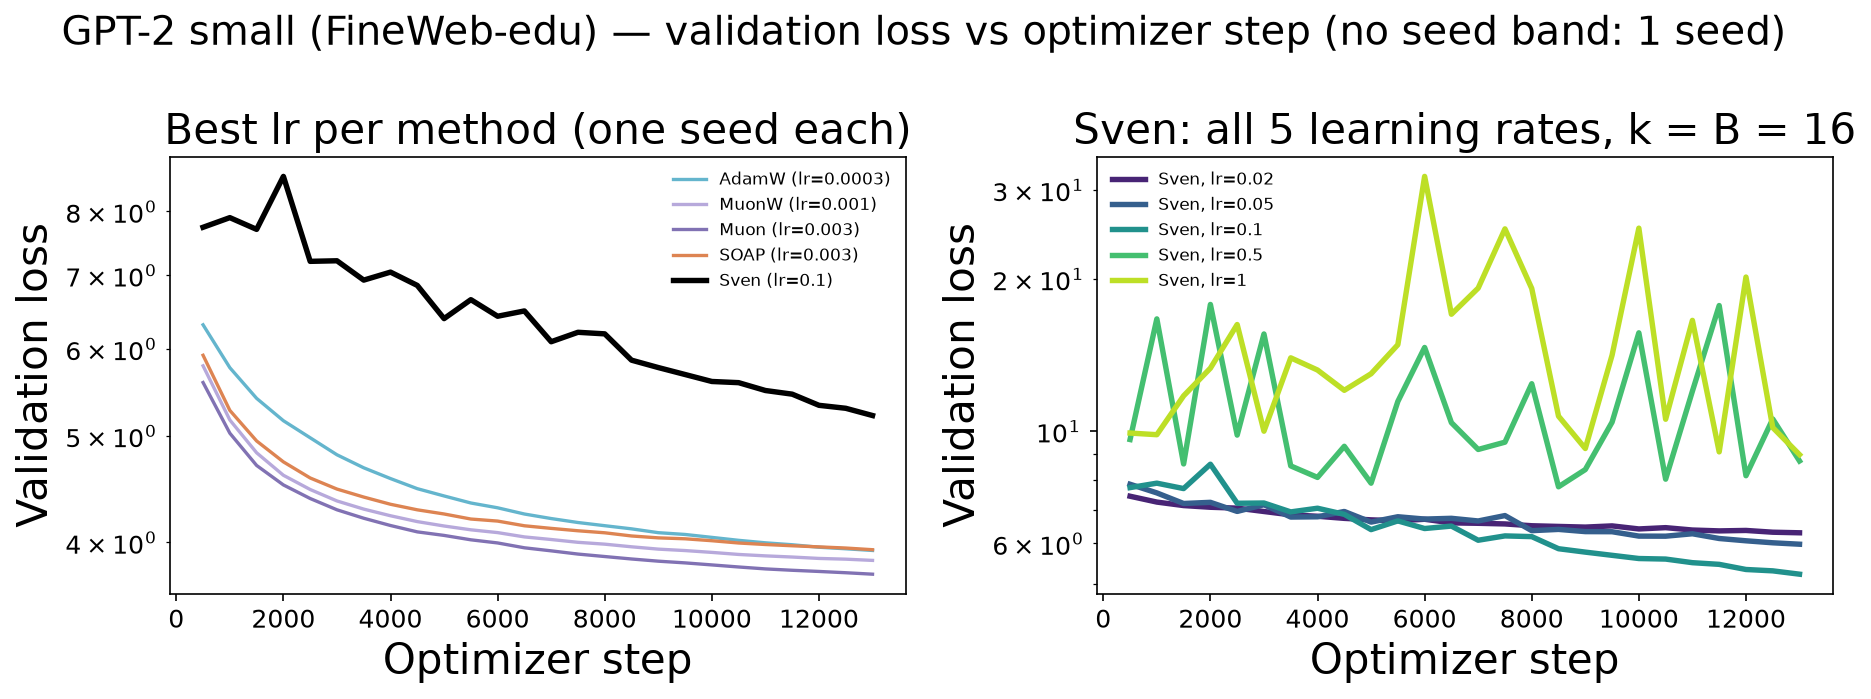

In [3]:
BEST = lf.gpt2_best_per_method(df)
show(BEST[['display', 'lr', 'val', 'test', 'val_ppl', 'wall_h', 'ms_per_step',
           'peak_gpu_mem_mb', 'attempted']],
     f'{TITLE} — best learning rate per method (selected on validation)')

best_rows = df[df['run_id'].isin(BEST['run_id'])]
sven_rows = df[df.method == 'Sven'].sort_values('lr')
cmap = plt.get_cmap('viridis')
lrs = sorted(sven_rows['lr'].unique())

fig, axes = plt.subplots(1, 2, figsize=(12.6, 4.8))
lf.plot_gpt2_curves(axes[0], best_rows, 'val_step')
axes[0].set_title('Best lr per method (one seed each)')
lf.plot_gpt2_curves(
    axes[1], sven_rows, 'val_step',
    label_fn=lambda r: f"Sven, lr={r['lr']:g}",
    color_fn=lambda r: cmap(0.1 + 0.8 * lrs.index(r['lr']) / max(len(lrs) - 1, 1)))
axes[1].set_title(f'Sven: all {len(lrs)} learning rates, k = B = '
                  f'{int(sven_rows["k"].iloc[0])}')
for ax in axes:
    ax.set_yscale('log'); ax.legend(fontsize=8)
fig.suptitle(f'{TITLE} — validation loss vs optimizer step (no seed band: 1 seed)')
fig.tight_layout()
print(lf.savefig(fig, 'gpt2_val_vs_step', PLOT_DIR)[0])
plt.show()

plots_v2/gpt2/gpt2_val_test_vs_step.pdf


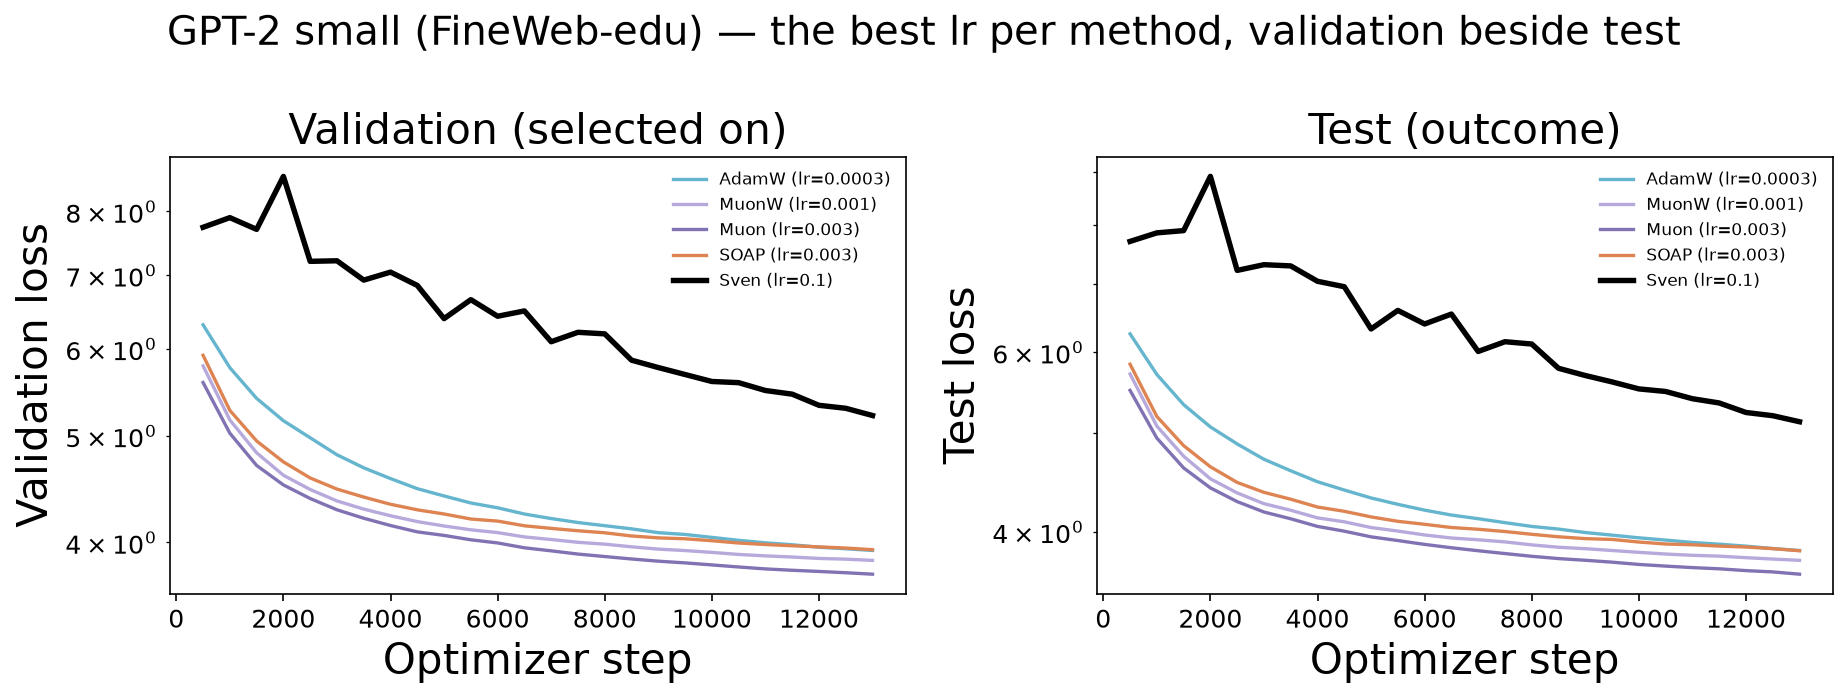


### the step curve at its last evaluation vs the end-of-epoch value
| method | lr | val@final step | test@final step | val (end of epoch) | test (end of epoch) |
|---|---|---|---|---|---|
| Muon | 0.003 | 3.742 | 3.634 | 3.741 | 3.632 |
| MuonW | 0.001 | 3.852 | 3.749 | 3.846 | 3.742 |
| AdamW | 0.0003 | 3.933 | 3.834 | 3.925 | 3.826 |
| SOAP | 0.003 | 3.939 | 3.831 | 3.935 | 3.825 |
| Sven | 0.1 | 5.217 | 5.127 | 5.198 | 5.107 |


,method,lr,val@final step,test@final step,val (end of epoch),test (end of epoch)
0,Muon,0.003,3.742164,3.634143,3.741049,3.631776
1,MuonW,0.001,3.851821,3.749472,3.845733,3.741530
2,AdamW,0.0003,3.932783,3.833745,3.925106,3.826375
3,SOAP,0.003,3.939048,3.831478,3.935204,3.824751
4,Sven,0.1,5.217246,5.126938,5.198449,5.106650


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12.6, 4.8))
for ax, key in zip(axes, ('val_step', 'test_step')):
    lf.plot_gpt2_curves(ax, best_rows, key)
    ax.set_yscale('log'); ax.legend(fontsize=8)
    ax.set_title({'val_step': 'Validation (selected on)',
                  'test_step': 'Test (outcome)'}[key])
fig.suptitle(f'{TITLE} — the best lr per method, validation beside test')
fig.tight_layout()
print(lf.savefig(fig, 'gpt2_val_test_vs_step', PLOT_DIR)[0])
plt.show()

last = pd.DataFrame([
    {'method': method_label(r['method']), 'lr': f"{r['lr']:g}",
     'val@final step': lf.gpt2_step_curve(r, 'val_step')[1][-1],
     'test@final step': lf.gpt2_step_curve(r, 'test_step')[1][-1],
     'val (end of epoch)': r['final_val_loss'], 'test (end of epoch)': r['final_test_loss']}
    for _, r in best_rows.sort_values('final_val_loss').iterrows()])
show(last, 'the step curve at its last evaluation vs the end-of-epoch value')

## 3. Learning-rate sensitivity

One run per point, so the vertical axis carries no uncertainty at all. What it can show is
the *shape*: whether a method's optimum is interior (it was found) or on an edge of its
sweep (it was not).

plots_v2/gpt2/gpt2_lr_sensitivity.pdf


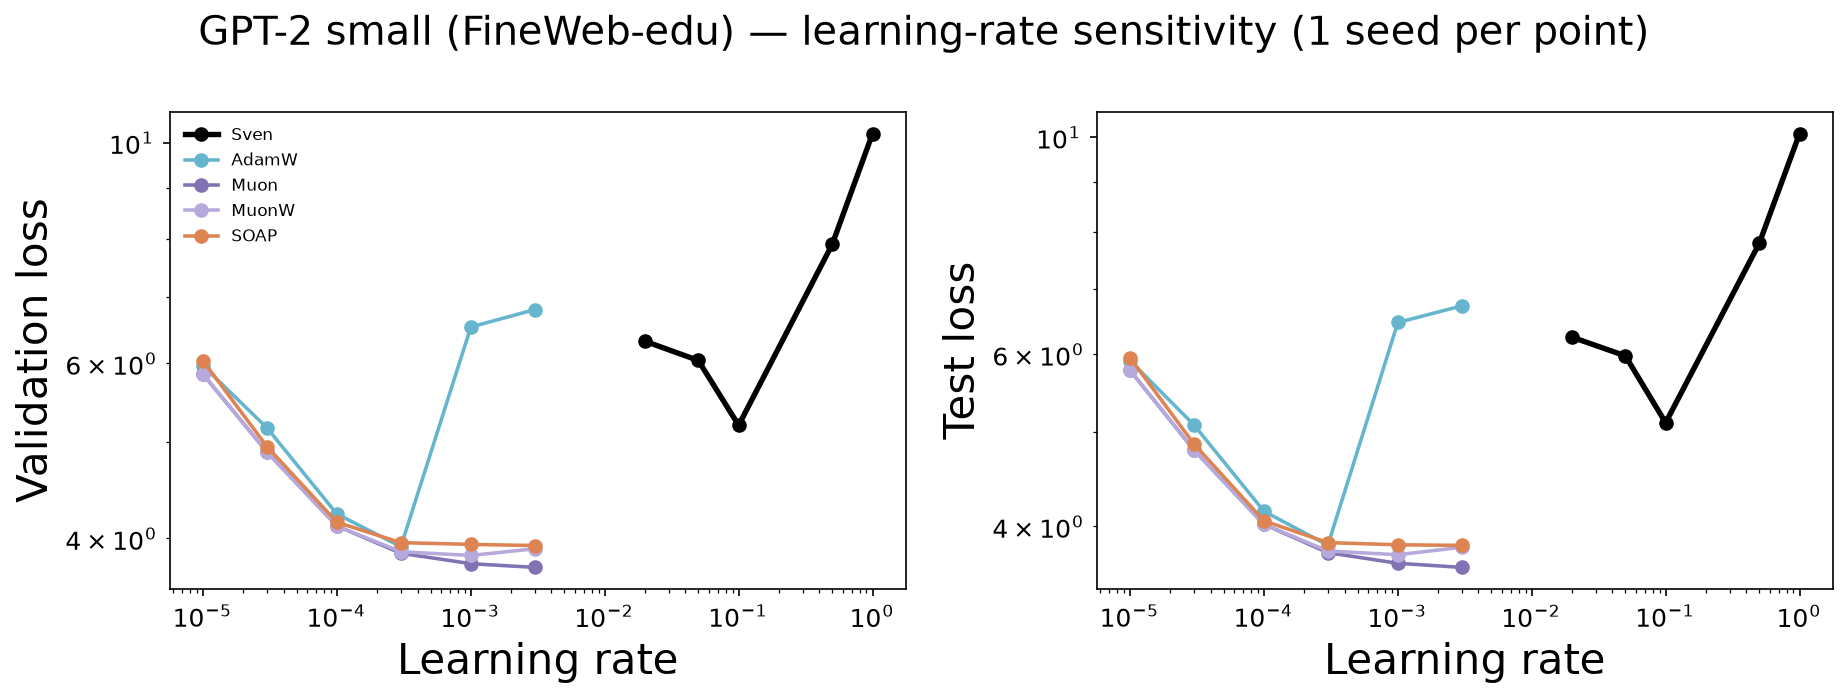


### is each method's optimum inside its sweep?
| method | lrs tried | best lr | best val | optimum | val at worst lr | spread (worst/best) |
|---|---|---|---|---|---|---|
| Sven | 5 | 0.1 | 5.198 | interior | 10.21 | 1.965 |
| AdamW | 6 | 0.0003 | 3.925 | interior | 6.795 | 1.731 |
| Muon | 6 | 0.003 | 3.741 | HIGH edge | 5.849 | 1.563 |
| MuonW | 6 | 0.001 | 3.846 | interior | 5.851 | 1.521 |
| SOAP | 6 | 0.003 | 3.935 | HIGH edge | 6.033 | 1.533 |


,method,lrs tried,best lr,best val,optimum,val at worst lr,spread (worst/best)
0,Sven,5,0.1,5.198449,interior,10.212676,1.964562
1,AdamW,6,0.0003,3.925106,interior,6.795130,1.731197
2,Muon,6,0.003,3.741049,HIGH edge,5.848759,1.563401
3,MuonW,6,0.001,3.845733,interior,5.850527,1.521304
4,SOAP,6,0.003,3.935204,HIGH edge,6.033159,1.533125


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12.6, 4.8))
for ax, col, name in zip(axes, ('val', 'test'), ('Validation loss', 'Test loss')):
    for method, sub in LR.groupby('method', sort=False):
        sub = sub.sort_values('lr')
        ax.plot(sub['lr'], sub[col], 'o-', color=method_color(method),
                lw=2.6 if method == 'Sven' else 1.7, label=method_label(method))
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlabel('Learning rate'); ax.set_ylabel(name)
axes[0].legend(fontsize=8)
fig.suptitle(f'{TITLE} — learning-rate sensitivity (1 seed per point)')
fig.tight_layout()
print(lf.savefig(fig, 'gpt2_lr_sensitivity', PLOT_DIR)[0])
plt.show()

rows = []
for method, sub in LR.groupby('method', sort=False):
    sub = sub.sort_values('lr')
    v = pd.to_numeric(sub['val'], errors='coerce')
    i = int(np.nanargmin(v))
    edge = 'interior' if 0 < i < len(sub) - 1 else ('LOW edge' if i == 0 else 'HIGH edge')
    rows.append({'method': method_label(method), 'lrs tried': len(sub),
                 'best lr': f"{sub['lr'].iloc[i]:g}", 'best val': v.iloc[i],
                 'optimum': edge,
                 'val at worst lr': float(np.nanmax(v)),
                 'spread (worst/best)': float(np.nanmax(v) / v.iloc[i])})
show(pd.DataFrame(rows), 'is each method\'s optimum inside its sweep?')

## 4. What it cost

Wall clock and peak memory are the runs' own: this lane ran one job per GPU (`NPROC 1`) on
A100-SXM4-80GB, so — unlike the sharded scans — a run's wall clock is already the
standalone number and needs no separate timing pass.

plots_v2/gpt2/gpt2_cost.pdf


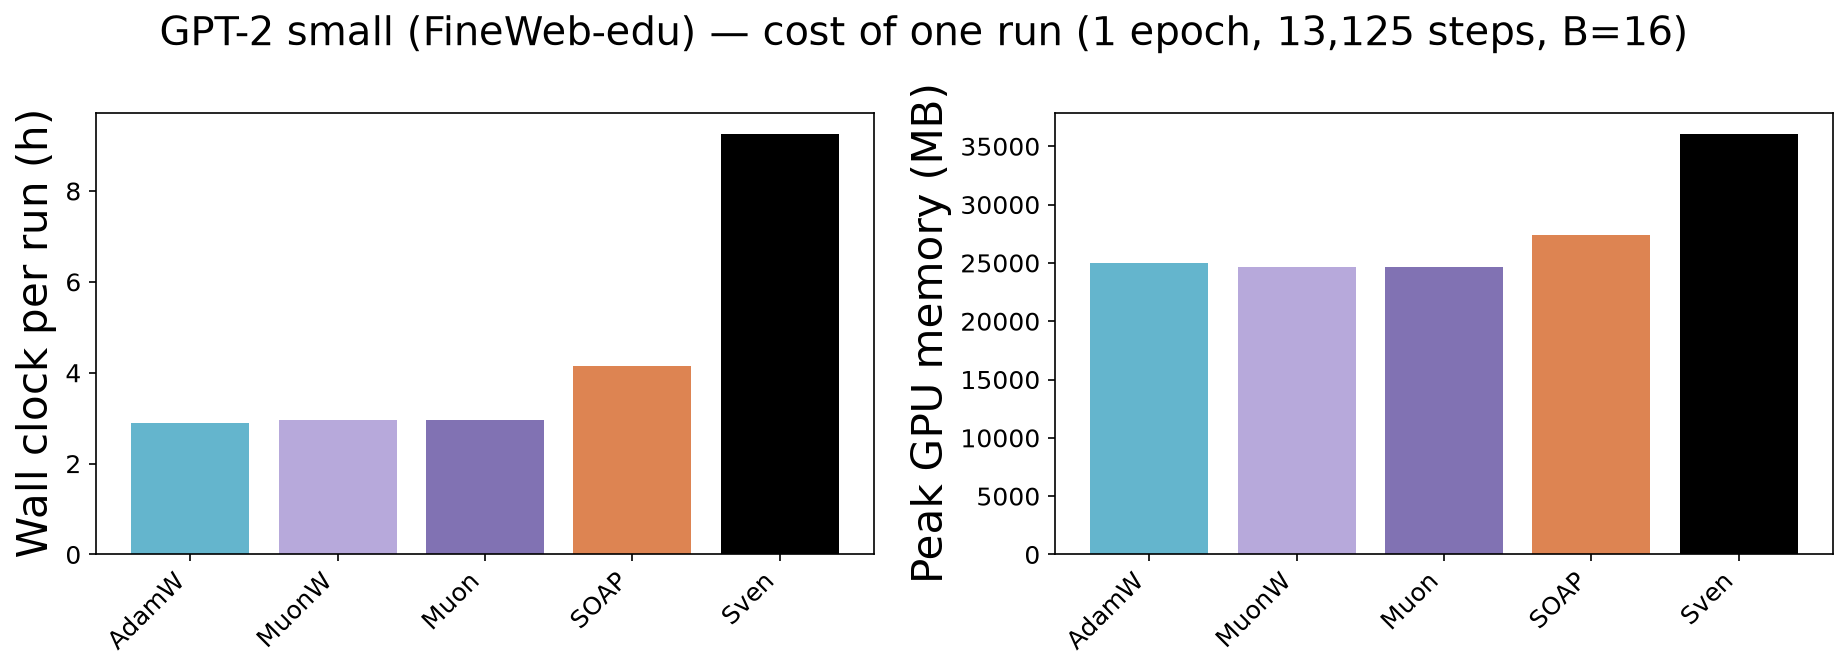


### GPT-2 small (FineWeb-edu) — final table (one seed per row)
| method | best lr | val loss | val ppl | test loss | wall (h) | x fastest | ms/step | peak mem (MB) | lrs tried (fin/att) |
|---|---|---|---|---|---|---|---|---|---|
| Muon | 0.003 | 3.741 | 42.14 | 3.632 | 2.95 | 1.02x | 793.1 | 24650 | 6/6 |
| MuonW | 0.001 | 3.846 | 46.79 | 3.742 | 2.95 | 1.02x | 793.4 | 24650 | 6/6 |
| AdamW | 0.0003 | 3.925 | 50.66 | 3.826 | 2.89 | 1.00x | 775.8 | 24990 | 6/6 |
| SOAP | 0.003 | 3.935 | 51.17 | 3.825 | 4.15 | 1.43x | 1120 | 27391 | 6/6 |
| Sven | 0.1 | 5.198 | 181 | 5.107 | 9.25 | 3.20x | 2517 | 36050 | 5/5 |


,method,best lr,val loss,val ppl,test loss,wall (h),x fastest,ms/step,peak mem (MB),lrs tried (fin/att)
0,Muon,0.003,3.741,42.14,3.632,2.95,1.02x,793.1,24650,6/6
1,MuonW,0.001,3.846,46.79,3.742,2.95,1.02x,793.4,24650,6/6
2,AdamW,0.0003,3.925,50.66,3.826,2.89,1.00x,775.8,24990,6/6
3,SOAP,0.003,3.935,51.17,3.825,4.15,1.43x,1120,27391,6/6
4,Sven,0.1,5.198,181,5.107,9.25,3.20x,2517,36050,5/5


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12.6, 4.6))
order = BEST.sort_values('wall_h')
x = np.arange(len(order))
for ax, col, ylabel in ((axes[0], 'wall_h', 'Wall clock per run (h)'),
                        (axes[1], 'peak_gpu_mem_mb', 'Peak GPU memory (MB)')):
    ax.bar(x, pd.to_numeric(order[col], errors='coerce'),
           color=[method_color(m) for m in order['method']])
    ax.set_xticks(x)
    ax.set_xticklabels([method_label(m) for m in order['method']], rotation=45, ha='right')
    ax.set_ylabel(ylabel)
fig.suptitle(f'{TITLE} — cost of one run (1 epoch, 13,125 steps, B=16)')
fig.tight_layout()
print(lf.savefig(fig, 'gpt2_cost', PLOT_DIR)[0])
plt.show()

show(lf.gpt2_summary_view(BEST), f'{TITLE} — final table (one seed per row)')

## 5. The framing, computed

Recomputed from the tables above; nothing below is typed in.

In [7]:
b = BEST.set_index('method')
val = pd.to_numeric(b['val'], errors='coerce')
base = val.drop('Sven')
sven_val, sven_test = float(val['Sven']), float(b.loc['Sven', 'test'])
winner = base.idxmin()
print(f'### {TITLE} — a single-seed negative scaling data point')
print(f'* Sven reaches validation {sven_val:.4g} (perplexity '
      f'{np.exp(sven_val):.4g}) against {base.min():.4g}–{base.max():.4g} for the '
      f'{len(base)} baselines; best baseline {method_label(winner)} at {base.min():.4g}. '
      f'Sven is {100 * (sven_val / base.min() - 1):+.0f}% on validation loss and last of '
      f'{len(val)}.')
print(f'* Test follows validation: Sven {sven_test:.4g} against '
      f'{pd.to_numeric(b["test"], errors="coerce").drop("Sven").min():.4g}–'
      f'{pd.to_numeric(b["test"], errors="coerce").drop("Sven").max():.4g}.')
print(f'* Cost: {b.loc["Sven", "wall_h"]:.2f} h per run against '
      f'{b["wall_h"].drop("Sven").min():.2f}–{b["wall_h"].drop("Sven").max():.2f} h '
      f'(x{b.loc["Sven", "wall_h"] / b["wall_h"].drop("Sven").min():.1f} the fastest), '
      f'{b.loc["Sven", "ms_per_step"]:.0f} ms/step against '
      f'{b["ms_per_step"].drop("Sven").min():.0f}–'
      f'{b["ms_per_step"].drop("Sven").max():.0f} ms, peak memory '
      f'{b.loc["Sven", "peak_gpu_mem_mb"]:.0f} MB against '
      f'{b["peak_gpu_mem_mb"].drop("Sven").min():.0f}–'
      f'{b["peak_gpu_mem_mb"].drop("Sven").max():.0f} MB '
      f'(x{b.loc["Sven", "peak_gpu_mem_mb"] / b["peak_gpu_mem_mb"].drop("Sven").min():.2f}).')
sven_lrs = sorted(df[df.method == 'Sven']['lr'].unique())
i = sven_lrs.index(float(b.loc['Sven', 'lr']))
print(f'* Sven\'s optimum is {"INTERIOR" if 0 < i < len(sven_lrs) - 1 else "on an EDGE"} '
      f'to its lr sweep [{", ".join(f"{x:g}" for x in sven_lrs)}] '
      f'(best {b.loc["Sven", "lr"]:g}), so the learning rate is '
      f'not what is missing; k = B = {int(df[df.method == "Sven"]["k"].iloc[0])} was fixed '
      f'and never swept, and that is the untuned knob.')
print(f'* Caveats that bound every line above: {int(df["model_seed"].nunique())} model '
      f'seed, {int(facts["num_epochs"])} epoch ({int(facts["steps_per_epoch"]):,} steps), '
      f'{int(df["diverged"].sum())} diverged runs of {len(df)}. With one seed a difference '
      f'smaller than the seed spread seen on the other scans is not a difference; the gap '
      f'reported here is far larger than that, which is why it is reportable at all.')
print(f'* The four legacy GPT-2 records (contaminated v1 token split) are NOT read here: '
      f'results root {ROOT.name}.')

### GPT-2 small (FineWeb-edu) — a single-seed negative scaling data point
* Sven reaches validation 5.198 (perplexity 181) against 3.741–3.935 for the 4 baselines; best baseline Muon at 3.741. Sven is +39% on validation loss and last of 5.
* Test follows validation: Sven 5.107 against 3.632–3.826.
* Cost: 9.25 h per run against 2.89–4.15 h (x3.2 the fastest), 2517 ms/step against 776–1120 ms, peak memory 36050 MB against 24650–27391 MB (x1.46).
* Sven's optimum is INTERIOR to its lr sweep [0.02, 0.05, 0.1, 0.5, 1] (best 0.1), so the learning rate is not what is missing; k = B = 16 was fixed and never swept, and that is the untuned knob.
* Caveats that bound every line above: 1 model seed, 1 epoch (13,125 steps), 0 diverged runs of 29. With one seed a difference smaller than the seed spread seen on the other scans is not a difference; the gap reported here is far larger than that, which is why it is reportable at all.
* The four legacy GPT-2 records (contaminated v1 token split) are NOT